In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nflreadpy as nfl

In [2]:
draft_url = "https://github.com/nflverse/nflverse-data/releases/download/draft_picks/draft_picks.csv"
draft = pd.read_csv(draft_url)

In [7]:
draft = draft[(draft["season"] >= 2000) & (draft["season"] <= 2020)]
draft = draft[draft['w_av'].notna()]

position_order = ['DB', 'WR', 'LB', 'DE', 'DT', 'RB', 'T', 'TE', 'G', 'QB', 'CB', 'C', 'S', 'OLB', 'FB',
                'K', 'P', 'ILB', 'OL', 'NT', 'LS', 'DL']

expected = pd.DataFrame(draft.groupby("pick")["w_av"].mean().reset_index().rename(columns={"w_av": "expected_w_av"}))

draft = draft.merge(expected, on='pick')

draft['ev_delta'] = draft['w_av'] - draft['expected_w_av']
draft['ev_ratio'] = draft['w_av'] / draft['expected_w_av']

expected = expected.set_index('pick')

pos_counts = pd.DataFrame(draft['position'].value_counts())
pos_counts = pos_counts.reindex(position_order)

pos_avg_dr_av = pd.DataFrame(draft.groupby('position')['dr_av'].mean())
pos_avg_dr_av = pos_avg_dr_av.reindex(position_order)

pos_w_av = pd.DataFrame(draft.groupby('position')['w_av'].mean())
pos_w_av = pos_w_av.reindex(position_order)

pos_ev_delta = pd.DataFrame(draft.groupby('position')['ev_delta'].mean())
pos_ev_delta = pos_ev_delta.reindex(position_order)

pos_ratio = pd.DataFrame(draft.groupby('position')['ev_ratio'].mean())
pos_ratio = pos_ratio.reindex(position_order)

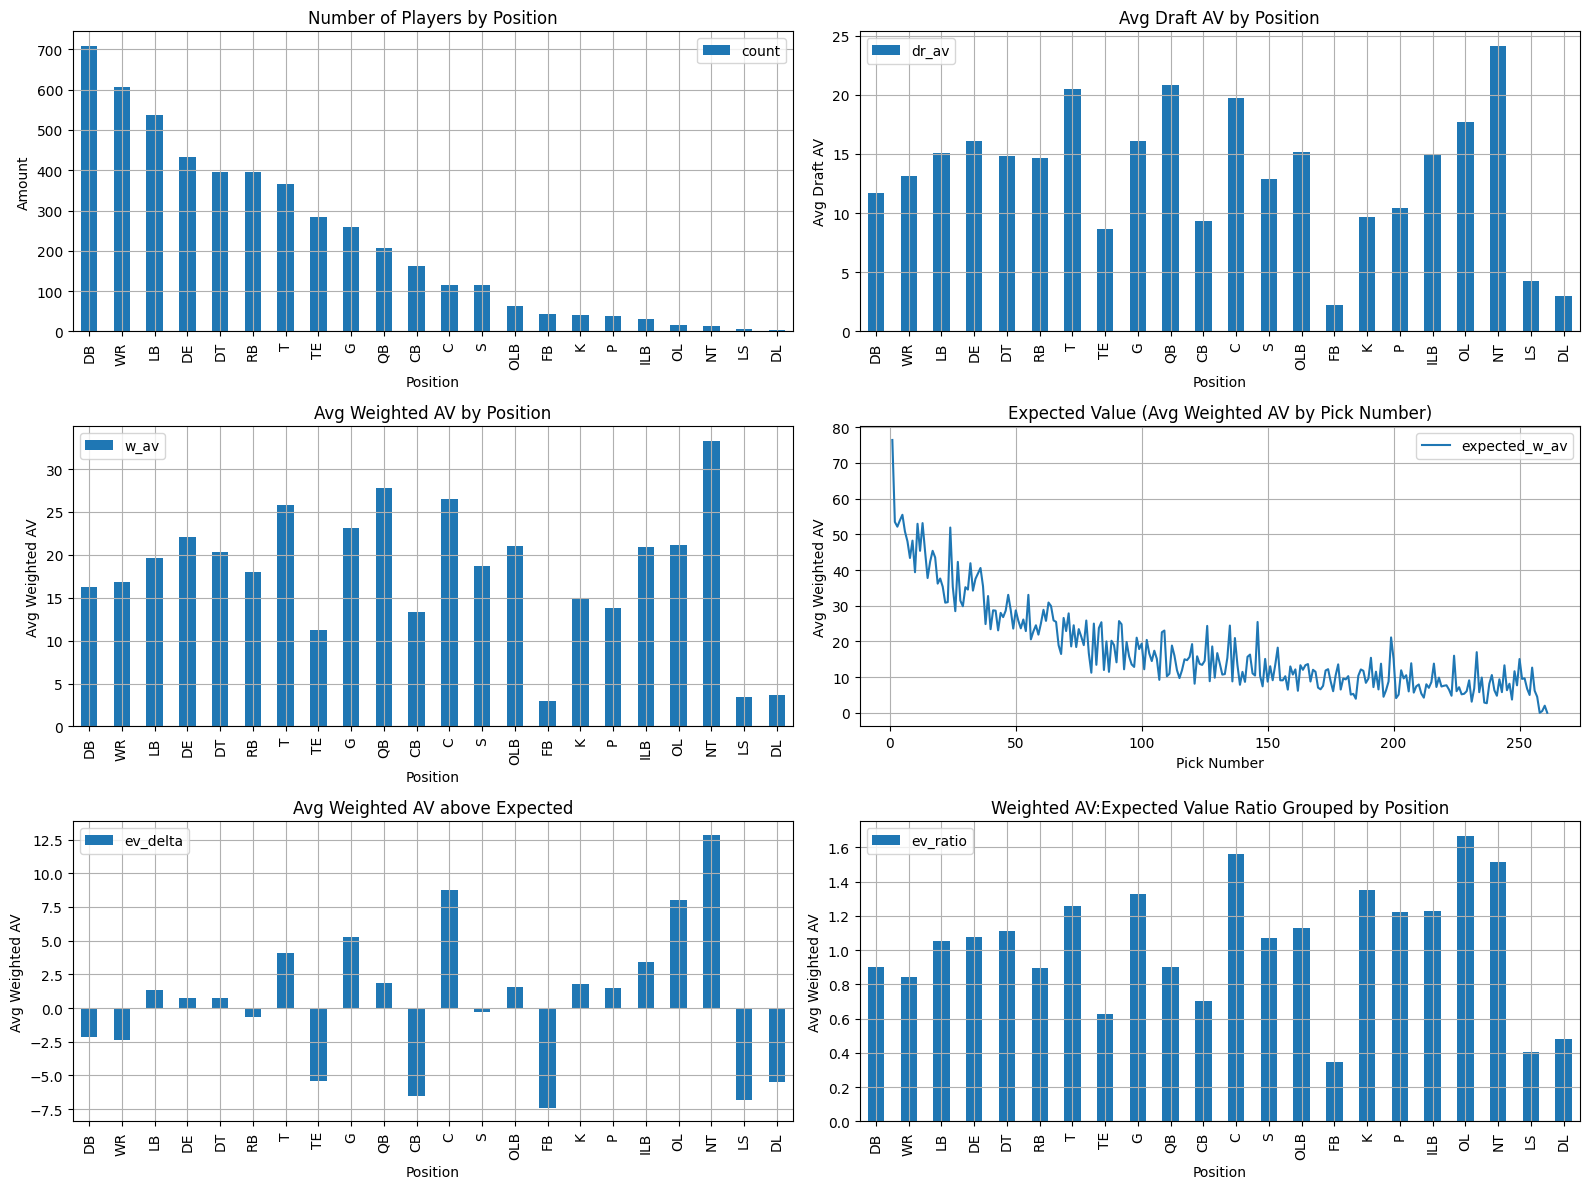

In [8]:

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

pos_counts.plot.bar(
    ax=axes[0, 0],
    title='Number of Players by Position',
    xlabel='Position',
    ylabel='Amount',
    grid=True,
)

pos_avg_dr_av.plot.bar(
    ax=axes[0, 1],
    title='Avg Draft AV by Position',
    xlabel='Position',
    ylabel='Avg Draft AV',
    grid=True,
)

pos_w_av.plot.bar(
    ax=axes[1, 0],
    title='Avg Weighted AV by Position',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

expected.plot.line(
    ax=axes[1, 1],
    title='Expected Value (Avg Weighted AV by Pick Number)',
    xlabel='Pick Number',
    ylabel='Avg Weighted AV',
    grid=True,
)

pos_ev_delta.plot.bar(
    ax=axes[2, 0],
    title='Avg Weighted AV above Expected',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

pos_ratio.plot.bar(
    ax=axes[2, 1],
    title='Weighted AV:Expected Value Ratio Grouped by Position',
    xlabel='Position',
    ylabel='Avg Weighted AV',
    grid=True,
)

plt.tight_layout()
plt.show()

In [129]:
contracts_url = "https://github.com/nflverse/nflverse-data/releases/download/contracts/historical_contracts.csv.gz"
contracts = pd.read_csv(contracts_url)
games = pd.read_csv('games (1).csv')
pfr_roster = pd.read_csv('pfr_rosters.csv')

C:\Users\SHANE\AppData\Local\Temp\ipykernel_16692\341449568.py:4: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  pfr_roster = pd.read_csv('pfr_rosters.csv')


In [130]:
games = games.drop(columns=['away_rest', 'home_rest',
       'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
       'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game',
       'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id',
       'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee',
       'stadium_id', 'stadium', 'old_game_id', 'gsis',
       'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'gameday', 'weekday',
       'gametime'])



games['home_win'] = (games['result'] > 0).astype(int)
games['away_loss'] = (games['result'] > 0).astype(int)
games['home_loss'] = (games['result'] < 0).astype(int)
games['away_win'] = (games['result'] < 0).astype(int)
games['tie'] = (games['result'] == 0).astype(int)



home_wins = pd.DataFrame()
home_wins = games.groupby(['season', 'home_team'])['home_win'].sum().reset_index()
home_wins = home_wins.rename(columns={'home_team': 'team'})

away_wins = pd.DataFrame()
away_wins = games.groupby(['season', 'away_team'])['away_win'].sum().reset_index()
away_wins = away_wins.rename(columns={'away_team': 'team'})

home_loss = pd.DataFrame()
home_loss = games.groupby(['season', 'home_team'])['home_loss'].sum().reset_index()
home_loss = home_loss.rename(columns={'home_team': 'team'})

away_loss = pd.DataFrame()
away_loss = games.groupby(['season', 'away_team'])['away_loss'].sum().reset_index()
away_loss = away_loss.rename(columns={'away_team': 'team'})

ties = pd.DataFrame()
ties = games.groupby(['season', 'home_team'])['tie'].sum().reset_index()
ties = ties.rename(columns={'home_team': 'team'})



seasons = pd.DataFrame()

seasons_win = pd.merge(home_wins, away_wins, on=['season', 'team'])
seasons_loss = pd.merge(home_loss, away_loss, on=['season', 'team'])

seasons_wl = pd.merge(seasons_win, seasons_loss, on=['season', 'team'])
seasons = pd.merge(seasons_wl, ties, on=['season', 'team'])

seasons['wins'] = seasons['home_win'] + seasons['away_win']
seasons['loss'] = seasons['home_loss'] + seasons['away_loss']
seasons['record'] = (
    seasons['wins'].astype(str) + '-' +
    seasons['loss'].astype(str) + '-' +
    seasons['tie'].astype(str)
)
seasons.tail()

,season,team,home_win,away_win,home_loss,away_loss,tie,wins,loss,record
856,2025,SEA,8,9,2,1,0,17,3,17-3-0
857,2025,SF,5,8,3,3,0,13,6,13-6-0
858,2025,TB,4,4,4,5,0,8,9,8-9-0
859,2025,TEN,1,2,8,6,0,3,14,3-14-0
860,2025,WAS,2,3,6,6,0,5,12,5-12-0


In [ ]:
# 2020 was final year of 16 games. Do flag of playoff games based on playing more than regular season amount. 
# also need win percentage, and possibly avg score differential per game as well as off ppg and def ppg